In [1]:
import pydpeet as eet
import matplotlib.pyplot as plt

OCVs are Importend for Analyzing Materials, Ageeing and for Parametrisiation of Models. Here the Funtion from [Squences](Tutorial_02_Sequence.ipynb) is used to automatically extract incremntall OCVs from Lab-Data and analyze it through DVA and ICA

In [2]:
Data = eet.convert.convert_file(config = 'Neware', input_path = r"..\..\res\raw\Cal_Ageing_Checkup3.xlsx")

converting file to pandas DataFrame...
Reading sheets from ..\..\res\raw\Cal_Ageing_Checkup3.xlsx...
hadling record auxvol auxtemp sheets...
checking if headers need to be reindexed...
reindexing headers...
Handling sheets cycle, step and test...
merging cycle and step...
handling test sheet...
merging cycle_step_test and test...
merging record and auxvol...
checking if headers need to be reindexed...
reindexing headers...
merging record_auxvol and auxtemp...


C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxvol.rename(columns={'Date': 'Date - auxVol', 'DataPoint': 'DataPoint - auxVol'}, inplace=True)
C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\convert\zyklisierer\neware\reader.py:286: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auxtemp.rename(columns={'Date': 'Date - auxTemp', 'DataPoint': 'DataPoint - auxTemp'}, inplace=True)


handling final merge...
mapping columns...
dropping additional data...
adding metadata to Dataframe...
Getting columns in correct order...
Checking for duplicate extra columns...
Selecting and ordering standard columns...
Selecting extra columns...
Combining standard and extra columns...
Reordered DataFrame columns!
Starting to fix data format...
Using formatter for config: Config.Neware
Data format fixed.
convert_file executed in 7.752897 seconds


In [3]:
Data_segmented = eet.process.sequence.step_analyzer_primitives(Data)
Data_segmented.head()

Input Warning: Using EXAMPLE_STEP_ANALYZER_PRIMITIVES_CONFIG as fallback configuration. Manual Parameters will be kept.
Input Warning: Dropping NaN values in 'Testtime[s]', dropping duplicates and sorting 'Testtime[s]' column.
    1.1758s precompiling step_analyzer_primitives and df_primitives_correction
detecting segments in dataframe of size 162369...
    0.0010s calculating Power[W]
    0.0011s separating Voltage[V] into segments using incremental linear fit
    0.0011s separating Current[A] into segments using incremental linear fit
    0.0011s separating Power[W] into segments using incremental linear fit
    0.0016s adding Length_Segment_Voltage[V] to calculate the dominating segments
    0.0015s adding Length_Segment_Current[A] to calculate the dominating segments
    0.0016s adding Length_Segment_Power[W] to calculate the dominating segments
    0.0054s suppressing smaller segments
    0.0224s attempting to merge neighboring segments
    0.0682s fine tuning width of constant se

,Metadata,StepID,Voltage[V],Current[A],Temperature[°C],Testtime[s],Absolute Time[yyyy-mm-dd hh:mm:ss],EISFreq[Hz],Zre[Ohm],Zim[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08


In [4]:
method = eet.process.analyze.SocMethod.WITH_RESET_WHEN_FULL

LGM50LT = eet.process.analyze.BatteryConfig(
    c_ref=4.75,
    max_voltage=4.2,
    min_voltage=2.5,
    min_current_diff = 1,
    max_time_diff = 0.5,
    min_voltage_diff = 0,
    ignore_negative_resistance_values = True
)


# Data = eet.process.analyze.add_soc(
#     df=Data[Data['Testtime[s]']>40000],
#     df_primitives=Data_segmented[Data_segmented['Testtime[s]']>40000],
#     standard_method=method,
#     config=LGM50LT
# )

Data = eet.process.analyze.add_soc(
    df=Data,
    df_primitives=Data_segmented,
    standard_method=method,
    config=LGM50LT
)

analyzing segments...
    0.0055s filtering by ID
    0.0068s tag simple segments
    0.0157s tag sequences
    0.1154s assign longest sequence


C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\analyze\calculations\soc_methods.py:190: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  warnings.warn("Column 'Capacity[Ah]' missing, adding with function add_capacity.")


    0.0010s separate sequences and df_with_segments
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 


In [5]:
Data.head()

,Metadata,StepID,Voltage[V],Current[A],Temperature[°C],Testtime[s],Absolute Time[yyyy-mm-dd hh:mm:ss],EISFreq[Hz],Zre[Ohm],Zim[Ohm],DC_Current[A],Capacity[Ah],SOC
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None,NaN,0.194992
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None,NaN,0.195076
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None,NaN,0.195160
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None,NaN,0.195244
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None,NaN,0.195329


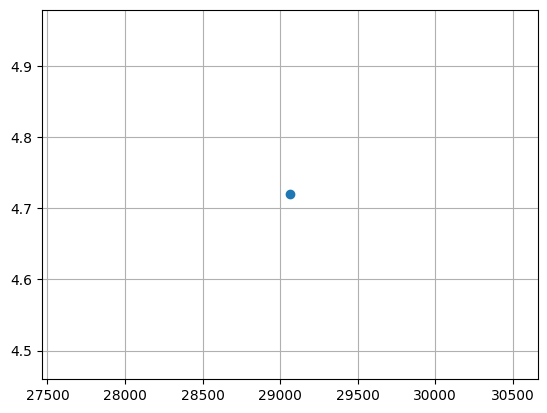

In [6]:
fig, ax = plt.subplots()

ax.scatter(Data['Testtime[s]'], Data['Capacity[Ah]'], label='SOC')
ax.grid()

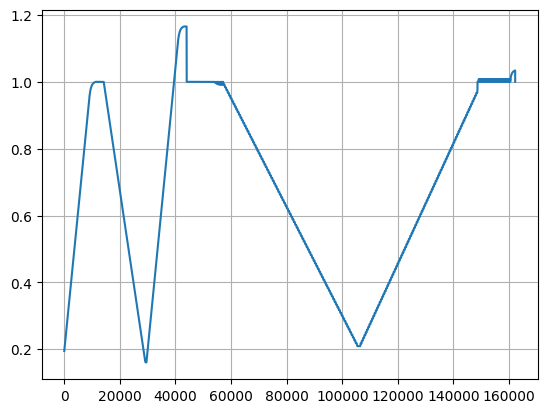

In [7]:
fig, ax = plt.subplots()

ax.plot(Data['Testtime[s]'], Data['SOC'], label='SOC')
ax.grid()

In [8]:
OCVs = eet.process.analyze.iocv_detection(df_primitives = Data_segmented, config = LGM50LT, visualize = False)

Checking if SOC exists in dataframe...
SOC column does not exist in df_primitives, adding it...
analyzing segments...
    0.0045s filtering by ID
    0.0070s tag simple segments
    0.0145s tag sequences
    0.1122s assign longest sequence
    0.0007s separate sequences and df_with_segments
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 


C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\analyze\calculations\soc_methods.py:190: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  warnings.warn("Column 'Capacity[Ah]' missing, adding with function add_capacity.")


 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 
analyzing segments...
    0.0036s filtering by ID
    0.0069s tag simple segments
    0.0100s tag sequences
    0.0029s assign longest sequence
    0.0005s separate sequences and df_with_segments
Applying rules and standard columns to compute iOCV blocks...
 Input Warning: Using default standard columns: ['Testtime[s]', 'Voltage[V]', 'Current[A]', 'Power[W]'] 
----------------------------------------
Block 0:
  Start ID: 3, Testtime[s]: 11306.8
  End ID:   4, Testtime[s]: 29061.8
----------------------------------------
----------------------------------------
Block 1:
  Start ID: 6, Testtime[s]: 29492.7
  End ID:   7, Testtime[s]: 40726.7
----------------------------------------
----------------------------------------
Block 2:
  Start ID: 9, Testtime[s]: 43103.6
  End ID:   252, Testtime[s]: 105285.0
----------------------------------------
----------------------------------------

In [9]:
OCVs[0].head()

,Testtime[s],Voltage[V],Current[A],Power[W],ID,Power[W],Metadata,StepID,Temperature[°C],Absolute Time[yyyy-mm-dd hh:mm:ss],...,Length,Min,Max,Avg,Type,Direction,Slope,Capacity[Ah],SOC,iOCV_type
44008.0,44002.6,4.1934,0.0,0.0,9,0.0,None,5.0,25.7,2024-04-19 22:19:24,...,899.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
44516.0,44508.1,4.1683,0.0,0.0,11,0.0,None,7.0,25.9,2024-04-19 22:27:50,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
45024.0,45013.6,4.1500,0.0,0.0,13,0.0,None,9.0,25.7,2024-04-19 22:36:16,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
45532.0,45519.1,4.1361,0.0,0.0,15,0.0,None,11.0,25.7,2024-04-19 22:44:41,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
46040.0,46024.6,4.1252,0.0,0.0,17,0.0,None,13.0,25.7,2024-04-19 22:53:07,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge


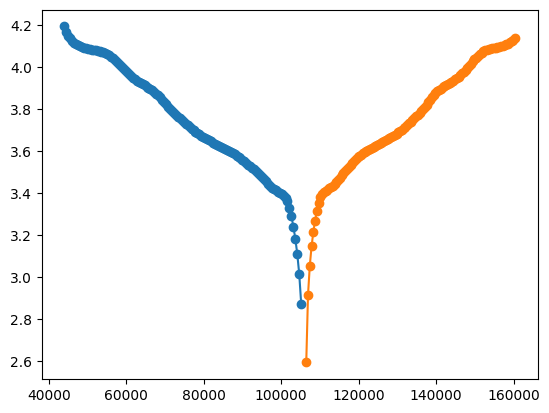

In [10]:
fig, ax = plt.subplots()

for OCV in OCVs:
    ax.plot(OCV['Testtime[s]'], OCV['Voltage[V]'], marker='o', linestyle='-', label='iOCV Points')

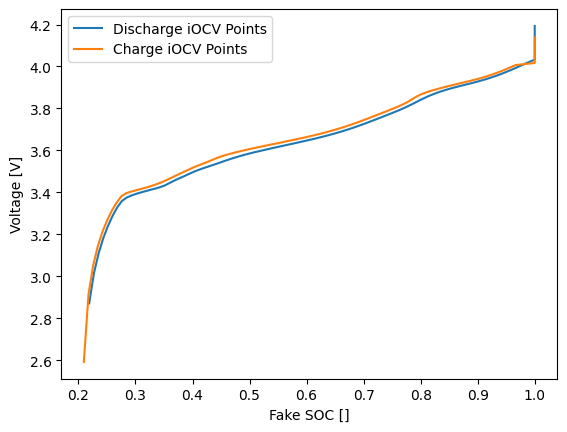

In [11]:
fig, ax = plt.subplots()

for OCV in OCVs:
    ax.plot(OCV['SOC'], OCV['Voltage[V]'], linestyle='-', label=f'{OCV['iOCV_type'].iloc[0]} iOCV Points')
    ax.legend()
    ax.set_ylabel('Voltage [V]')
    ax.set_xlabel('Fake SOC []')